#En este cuaderno vamos a realizar la extraccion y limpieza de datos del TFM de energia nuclear


Dado que como todo en este mundo depende de infindad de variables, y no podemos tenerlas en cuenta todas, nos vamos a centrar en lo siguiente,a ver que te parece

Datos del coste de energia y produccion energetica
     Precios historicos, gastos de generacion, produccion energetica total, factores de capacidad

Costo de implementacion y mantenimiento
     construccion de nuevas plantas, operacion y mantenimiento, desmantelamiento, trata de residuos nucleares

### Historicos energéticos

En este apartado sacaremos datos historicos de varias variables, el precio historico del kwh, el precio historico de los gastos de generacion, la produccion energetica total, y factores de capacidad total, de las dos principales fuentes de energia, que son la electrica y gas natural, y la energia nuclear


Datos que sí deberías obtener por fuente:

Costo de generación histórico por kWh (LCOE).

Producción energética total por fuente (nuclear, gas natural, renovables).

Factores de capacidad por fuente (cuánta energía genera realmente una planta respecto a su capacidad máxima).

El LCOE (Levelized Cost of Energy), o Costo Nivelado de Energía, es una métrica que se utiliza para calcular el costo total de producción de electricidad por unidad de energía (normalmente expresada en USD/MWh o €/MWh) durante toda la vida útil de una planta energética.



The US has the largest nuclear power plant fleet with 104 GW in 2018, followed by France (63 GW), China (45 GW), Japan (37 GW) and Russia (29 GW).
Por tanto un estudio basado en estados unidos seria optimo

Exctraemos los datos de energia nuclear del siguiente enlace

https://www.eia.gov/nuclear/data.php#nuclear

De aqui sacamos el Table8.1 energy overview


De aqui sacamos el dataset power plants database global

https://www.kaggle.com/datasets/alistairking/nuclear-energy-datasets

In [ ]:
#Insalamos las librerias para la api de open-meteo

!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas
!pip install ydata-profiling
!pip install skforecast

In [ ]:
import importlib.util
import subprocess

# Lista de paquetes que queremos instalar si no están presentes
packages = [
    "openmeteo-requests",
    "requests-cache",
    "retry-requests",
    "numpy",
    "pandas",
    "ydata-profiling",
    "skforecast"
]

# Función para verificar e instalar paquetes
def install_if_missing(package):
    if importlib.util.find_spec(package) is None:
        print(f"Instalando {package}...")
        subprocess.check_call(["pip", "install", package])
    else:
        print(f"{package} ya está instalado.")

# Iterar sobre la lista de paquetes
for package in packages:
    install_if_missing(package)

Instalando openmeteo-requests...
Instalando requests-cache...
Instalando retry-requests...
numpy ya está instalado.
pandas ya está instalado.
Instalando ydata-profiling...
skforecast ya está instalado.


In [ ]:
#Importamos las librerias básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import heatmap
import matplotlib.dates as mdates


In [ ]:
# Cargar el archivo Excel
file_path = '/content/Table_8.1_Nuclear_Energy_Overview.xlsx'
excel_data = pd.ExcelFile(file_path)

# Listar los nombres de las hojas para identificar su contenido
sheet_names = excel_data.sheet_names
sheet_names

# Cargar las hojas de datos para inspeccionar su contenido
monthly_data = excel_data.parse('Monthly Data')
annual_data = excel_data.parse('Annual Data')

# Mostrar las primeras filas de cada hoja
monthly_data.head(), annual_data.head()

# Buscar las primeras filas con datos válidos
monthly_data_clean = monthly_data.dropna(how='all').reset_index(drop=True)
annual_data_clean = annual_data.dropna(how='all').reset_index(drop=True)

# Mostrar las primeras filas después de limpiar las filas vacías
monthly_data_clean.head(10), annual_data_clean.head(10)

# Definir los encabezados de las columnas
column_headers = [
    "Date",
    "Total_Operable_Units",
    "Net_Summer_Capacity_MW",
    "Net_Generation_MWh",
    "Share_of_Electricity_Percent",
    "Capacity_Factor_Percent"
]

# Extraer datos válidos de las tablas
monthly_data_extracted = monthly_data_clean.iloc[7:].reset_index(drop=True)
monthly_data_extracted.columns = column_headers

annual_data_extracted = annual_data_clean.iloc[7:].reset_index(drop=True)
annual_data_extracted.columns = column_headers

# Convertir las fechas a formato datetime donde sea posible
monthly_data_extracted['Date'] = pd.to_datetime(monthly_data_extracted['Date'], errors='coerce')
annual_data_extracted['Date'] = pd.to_datetime(annual_data_extracted['Date'], errors='coerce', format='%Y')

# Convertir las columnas numéricas
numeric_columns = column_headers[1:]
for col in numeric_columns:
    monthly_data_extracted[col] = pd.to_numeric(monthly_data_extracted[col], errors='coerce')
    annual_data_extracted[col] = pd.to_numeric(annual_data_extracted[col], errors='coerce')

# Mostrar las tablas al usuario
monthly_data_extracted, annual_data_extracted

monthly_data_extracted.set_index('Date', inplace=True)
annual_data_extracted.set_index('Date', inplace=True)

In [ ]:
monthly_data_extracted.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 623 entries, 1973-01-01 to 2024-11-01
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Total_Operable_Units          381 non-null    float64
 1   Net_Summer_Capacity_MW        623 non-null    float64
 2   Net_Generation_MWh            623 non-null    int64  
 3   Share_of_Electricity_Percent  623 non-null    float64
 4   Capacity_Factor_Percent       623 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 29.2 KB


In [ ]:
monthly_data_extracted.describe().round(2)

,Total_Operable_Units,Net_Summer_Capacity_MW,Net_Generation_MWh,Share_of_Electricity_Percent,Capacity_Factor_Percent
count,381.00,623.00,623.00,623.00,623.00
mean,100.72,85.77,50012.00,17.23,76.72
std,7.85,23.15,19585.09,4.15,16.28
min,42.00,14.53,5697.00,3.90,34.60
25%,99.00,80.00,33108.00,15.80,61.25
50%,104.00,98.16,57509.00,18.80,79.50
75%,104.00,99.63,65202.00,20.10,92.10
max,112.00,102.21,74649.00,22.90,101.60


In [ ]:
#Vemos cuantos daots NAN tenemos
num_nan_rows_monthly = monthly_data_extracted['Total_Operable_Units'].isna().sum()
num_nan_rows_annual = annual_data_extracted['Total_Operable_Units'].isna().sum()

print(f"Filas con NaN en monthly_data_extracted: {num_nan_rows_monthly}")
print(f"Filas con NaN en annual_data_extracted: {num_nan_rows_annual}")

#Vemos que fechas tienen NaN
nan_indices = monthly_data_extracted[monthly_data_extracted.isna().any(axis=1)].index
print(nan_indices)

#vemos si hay nan despues de 1994 11 01 (No hay)
has_nans = monthly_data_extracted.loc['1994-12-01':].isna().any().any()
print(has_nans)

nan_rows_count = monthly_data_extracted.loc[:'1994-11-01'].isna().any(axis=1).sum()
no_nan_rows_count = (~monthly_data_extracted.loc[:'1994-11-01'].isna().any(axis=1)).sum()
print(f"Filas con NaN hasta 1994-11-01: {nan_rows_count}, Filas sin NaN hasta 1994-11-01: {no_nan_rows_count}")

Filas con NaN en monthly_data_extracted: 242
Filas con NaN en annual_data_extracted: 0
DatetimeIndex(['1973-01-01', '1973-02-01', '1973-03-01', '1973-04-01',
               '1973-05-01', '1973-06-01', '1973-07-01', '1973-08-01',
               '1973-09-01', '1973-10-01',
               ...
               '1994-02-01', '1994-03-01', '1994-04-01', '1994-05-01',
               '1994-06-01', '1994-07-01', '1994-08-01', '1994-09-01',
               '1994-10-01', '1994-11-01'],
              dtype='datetime64[ns]', name='Date', length=242, freq=None)
False
Filas con NaN hasta 1994-11-01: 242, Filas sin NaN hasta 1994-11-01: 21


In [ ]:
#Importamos librerias de plots
from matplotlib import pyplot as plt
from seaborn import heatmap
import matplotlib.dates as mdates

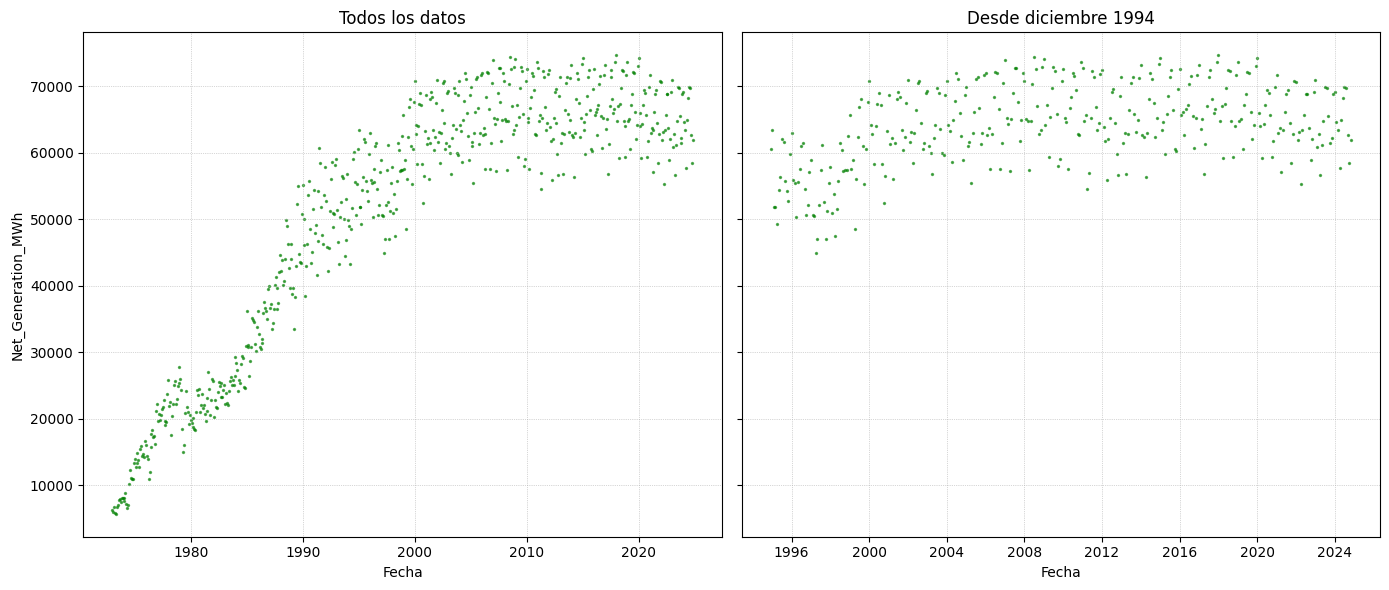

In [ ]:
import matplotlib.pyplot as plt

# Crear figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,6), sharey=True)  # sharey para compartir el mismo eje Y

# Estilo de puntos
scatter_style = {'color': 'green', 'alpha': 0.6, 's': 2}

# Gráfico 1: Todos los datos
axes[0].scatter(monthly_data_extracted.index, monthly_data_extracted['Net_Generation_MWh'], **scatter_style)
axes[0].set_title('Todos los datos')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Net_Generation_MWh')
axes[0].grid(True, linestyle=':', linewidth=0.5)

# Filtrar datos desde diciembre 1994 en adelante
filtered_data = monthly_data_extracted.loc['1994-12-01':]

# Gráfico 2: Datos desde diciembre 1994
axes[1].scatter(filtered_data.index, filtered_data['Net_Generation_MWh'], **scatter_style)
axes[1].set_title('Desde diciembre 1994')
axes[1].set_xlabel('Fecha')
axes[1].grid(True, linestyle=':', linewidth=0.5)

# Ajustar espacios
plt.tight_layout()
plt.show()


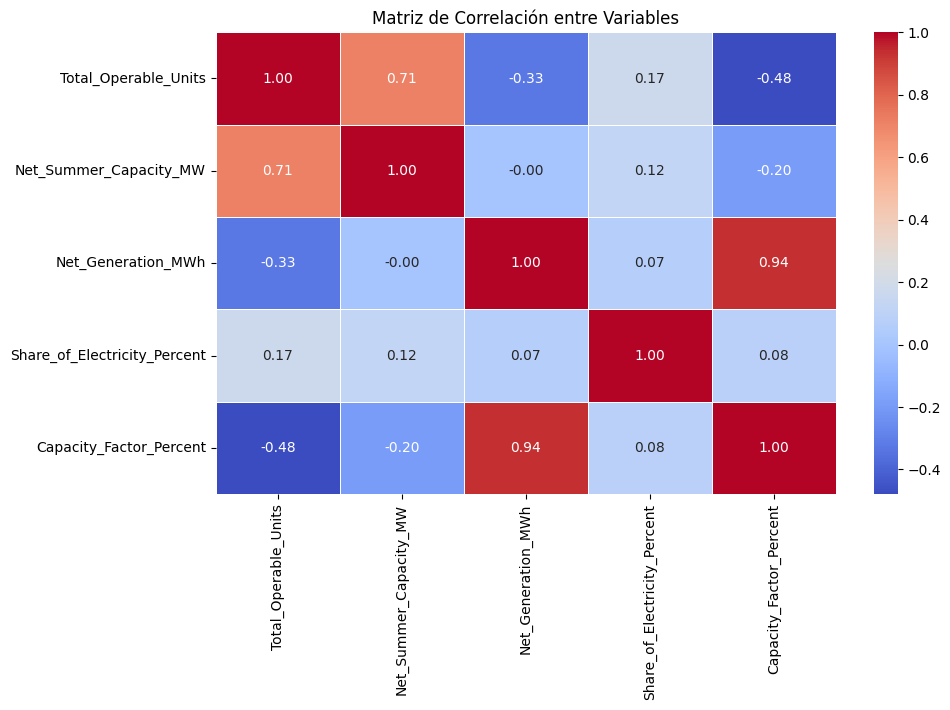

In [ ]:
# Crear un heatmap de correlación
plt.figure(figsize=(10,6))
sns.heatmap(filtered_data.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables")
plt.show()


###¿Por que quitamos las filas NaN?

En nuestro caso, las filas NaN, son la mayoria de los primeros años, para ser concretos, todos los años desde el primer dato, hasta diciembre de 1994, menos 21 meses repartidos en ese periodod e 1973 hasta 1994 tienen NaN en la columna de Operable Unnits, dado que no sabemos cuantas plantas nucleares habia activas, esto nos hace que no sea de confianza el resto de medidas, ya que no sabemos si las plantas son eficientes o no, además, dado que son datos de hace 50-30 años, la tecnología y política era muy distinta, por tanto, la eficiencia de las plantas en la época era muy distinta, y en una gráfica se puede ver que son outliers, por tanto, tiene sentido remover esos datos y no tenerlos en cuenta a la hora realizar análisis y ajustes


In [ ]:
print(monthly_data_extracted.isna().sum())

Total_Operable_Units            242
Net_Summer_Capacity_MW            0
Net_Generation_MWh                0
Share_of_Electricity_Percent      0
Capacity_Factor_Percent           0
dtype: int64


In [ ]:
#Eliminamos las filas NaN de monthly, y los datos antes de 1994, para evitar Nan y outliers
# Guardar las primeras filas (las que contienen NaN) en una copia aparte
old_data_backup = monthly_data_extracted.loc[:'1994-11-01'].copy()

# Dropear las filas antes de diciembre de 1994 en el DataFrame original
monthly_data_extracted = monthly_data_extracted.loc['1994-12-01':]

print(f"Filas con NaN en monthly_data_extracted: {monthly_data_extracted['Total_Operable_Units'].isna().sum()}")
print(f"Filas con NaN en annual_data_extracted: {annual_data_extracted['Total_Operable_Units'].isna().sum()}")
monthly_data_extracted.shape
monthly_data_extracted.head()

Filas con NaN en monthly_data_extracted: 0
Filas con NaN en annual_data_extracted: 0


,Total_Operable_Units,Net_Summer_Capacity_MW,Net_Generation_MWh,Share_of_Electricity_Percent,Capacity_Factor_Percent
Date,,,,,
1994-12-01,109.0,99.148,60497,22.4,82.0
1995-01-01,109.0,99.148,63342,22.6,85.9
1995-02-01,109.0,99.148,51858,20.6,77.8
1995-03-01,109.0,99.148,51880,19.9,70.3
1995-04-01,109.0,99.148,49321,20.2,69.2


##Vamos a visualizar las variables para analizar las tendencias de cada una de ellas


In [ ]:
#Importamos librerias de plots
from matplotlib import pyplot as plt
from seaborn import heatmap
import matplotlib.dates as mdates

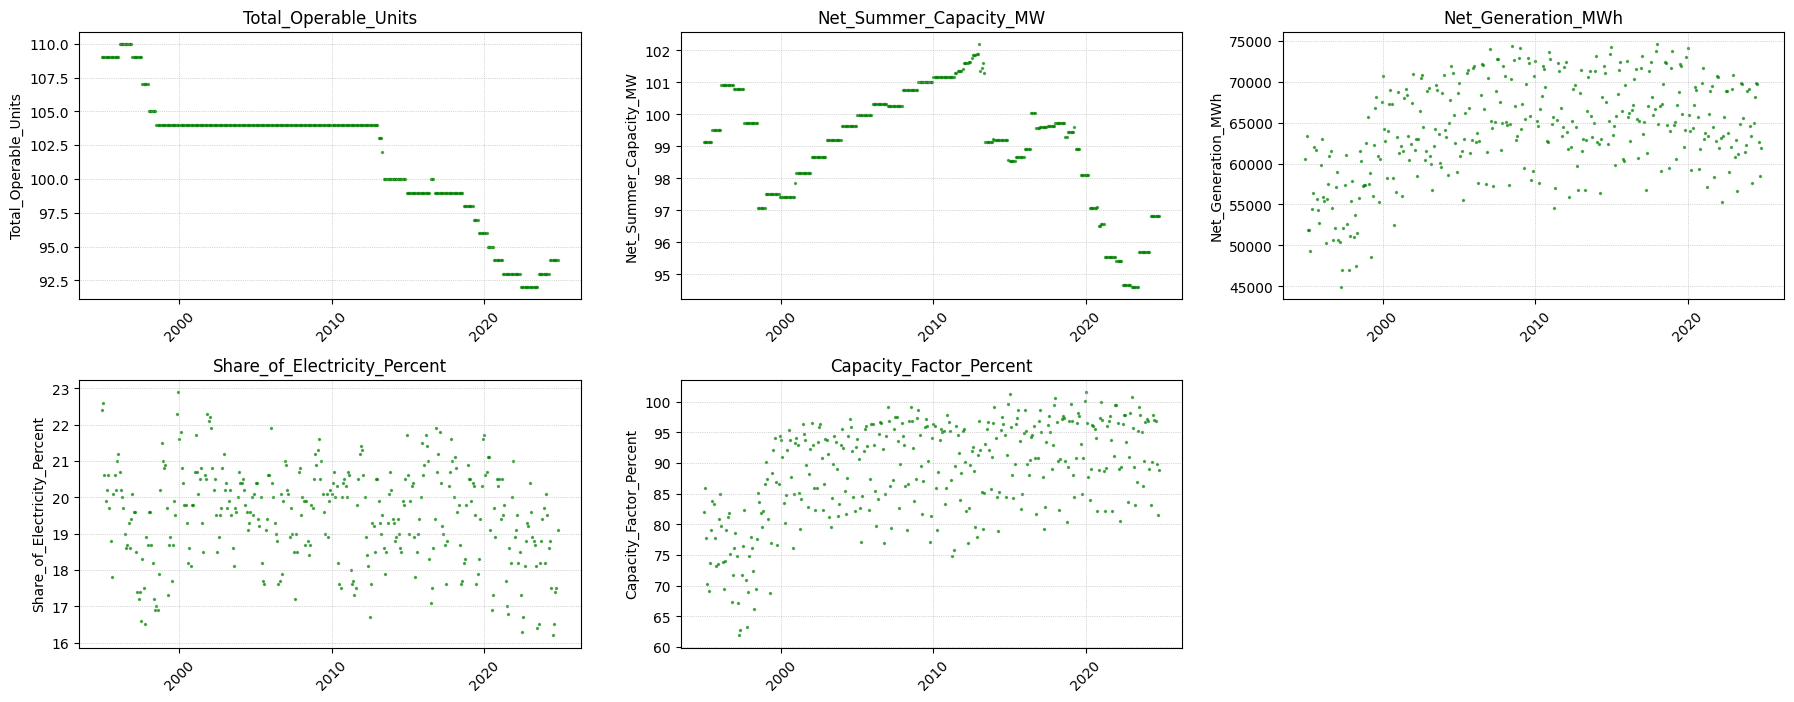

In [ ]:

# Crear figura más grande y con más separación
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(22, 8))
axes = axes.flatten()  # Aplanar los ejes

# Estilo de puntos más limpio
scatter_style = {'color': 'green', 'alpha': 0.6, 's': 2}  # Tamaño de puntos más pequeños

# Graficar cada variable como scatter plot
for i, column in enumerate(monthly_data_extracted.columns):
    axes[i].scatter(monthly_data_extracted.index, monthly_data_extracted[column], **scatter_style)
    axes[i].set_ylabel(column)
    axes[i].grid(True, linestyle=':', linewidth=0.5)  # Cuadrícula más sutil
    axes[i].set_title(f"{column}", fontsize=12)  # Títulos más pequeños

    # Fechas más espaciadas
    axes[i].xaxis.set_major_locator(mdates.YearLocator(10))  # Etiqueta cada 10 años
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=45, labelsize=10)

# Eliminar el último gráfico vacío (posición 5)
fig.delaxes(axes[len(monthly_data_extracted.columns)])

# Ajustar espacios entre gráficos
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()


####significado de cada columna en el contexto de la energía nuclear:

***Total Operable Units:***

Número total de reactores nucleares operativos en EE.UU. durante el período de tiempo correspondiente.
Solo se incluyen los reactores que están en funcionamiento y listos para generar electricidad.


***Capacidad neta en verano de las unidades nucleares*** (Nuclear Generating Units, Net Summer Capacity):

Es la capacidad máxima de generación de electricidad que pueden producir las plantas nucleares en condiciones de calor del verano.
Se mide en megavatios eléctricos (MWe) y representa la potencia máxima sostenida que una central puede suministrar en la red en esas condiciones.


***Generación neta de electricidad de energía nuclear*** (Nuclear Electricity Net Generation):

Es la cantidad total de electricidad generada por plantas nucleares menos la energía que ellas mismas consumen para su operación interna.
Se mide en gigavatios-hora (GWh) y representa la cantidad real de energía que llega a la red eléctrica.


***Participación de la energía nuclear en la generación total de electricidad ***(Nuclear Share of Electricity Net Generation):

Representa el porcentaje de electricidad en EE.UU. que proviene de la energía nuclear.
Se calcula dividiendo la electricidad generada por energía nuclear entre la generación total de electricidad en el país.


***Factor de capacidad de las unidades nucleares*** (Nuclear Generating Units, Capacity Factor):

Es el porcentaje de tiempo que las plantas nucleares operaron a su máxima capacidad teórica.
Se calcula como la energía realmente generada en un período dividido entre la cantidad que se habría producido si el reactor hubiera funcionado al 100% de su capacidad.
Un factor de capacidad alto (por ejemplo, >90%) indica que los reactores han estado operando casi todo el tiempo.



####Caida en la cantidad de plantas operativas

Hay dos periodos claros a partir de los cuales, se produjo una caída en la cantidad de plantas operativas, al rededor de 1990 y 2010.

Estos dos puntos de caída podrían concidir con los dos desastres mas conocidos, el de Chernobyl en 1986 y el de Fukushima en 2011.

Aun que no hay, decretos u órdenes directas sobre el desmantelamiento de plantas tras estos incidentes, es cierto que la opinión pública se vio afectada, y las medidas de seguridad y regulaciones se fortificaron.
Esto provocó que hubiera que modernizar las plantas nucleares, a nivel de infrastructura, de personal y protocolos, y sobre todo en plantas antiguas, hay que tener en cuenta que algunas se construyeron en los años 70, era simplemente mas eficiente a nivel económico desmantelarlas que modernizarlas, e incluso construir plantas nuevas.


##Transformaciones posibles


Dividir métricas por Total_Operable_Units	Comparar eficiencia por planta

Variación interanual (YoY %)	Analizar cambios a largo plazo

Media móvil (12 meses)	Suavizar fluctuaciones mensuales

Diferencias (diff())	Ver cambios abruptos mes a mes

Logaritmo (log1p())	Reducir la variabilidad de los datos



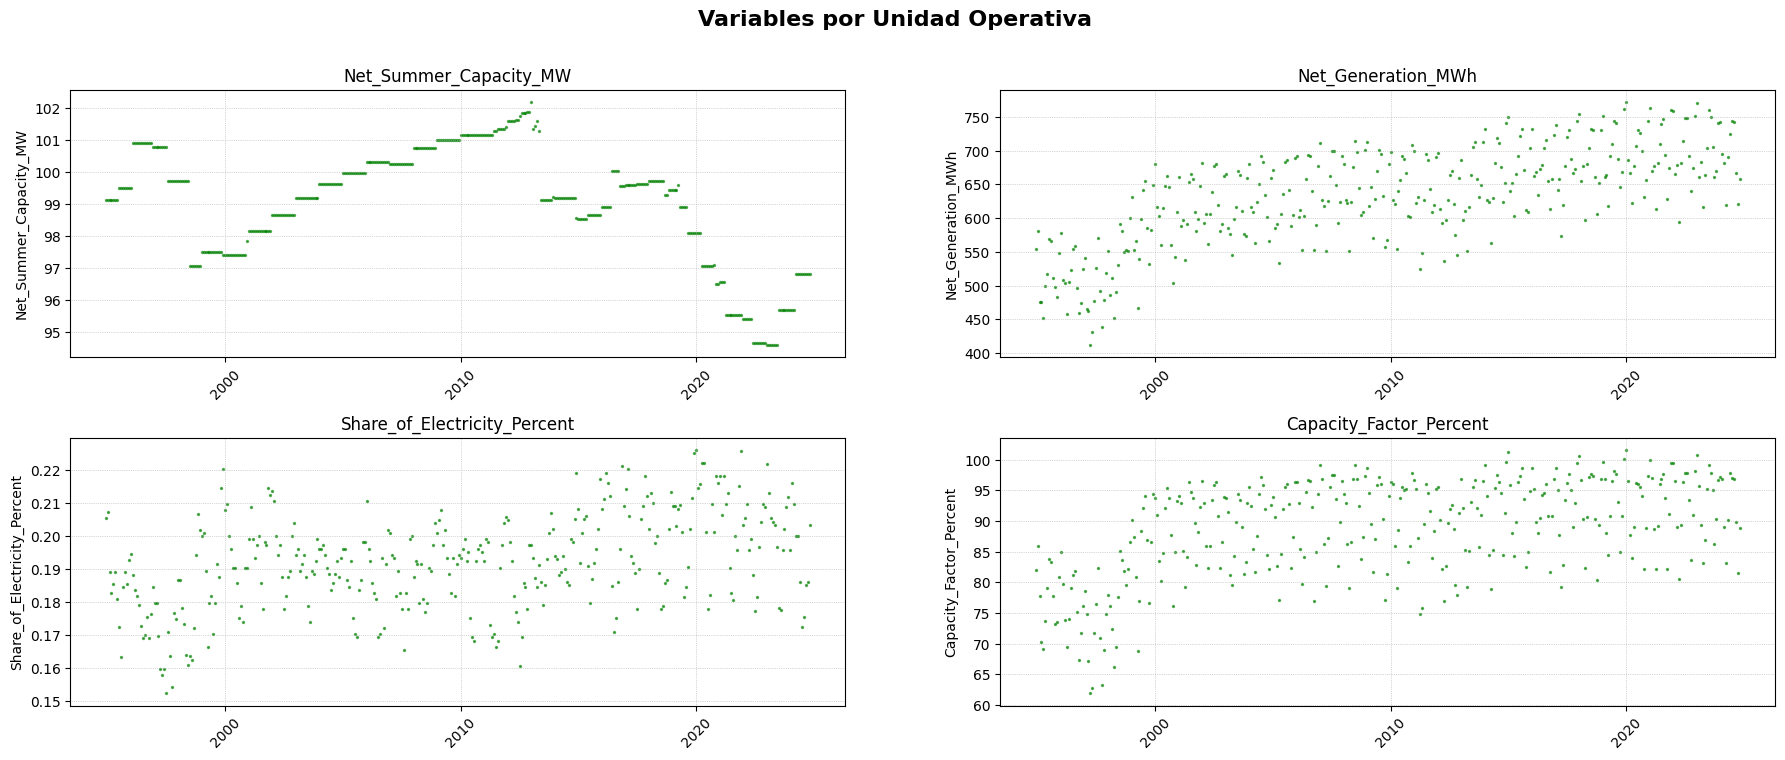

In [ ]:
#Variable por unidad operativa
monthly_data_per_unit = monthly_data_extracted.drop(columns=['Total_Operable_Units']).div(monthly_data_extracted['Total_Operable_Units'], axis=0)
monthly_data_per_unit['Net_Summer_Capacity_MW'] = monthly_data_extracted['Net_Summer_Capacity_MW']
monthly_data_per_unit['Capacity_Factor_Percent'] = monthly_data_extracted['Capacity_Factor_Percent']

# Crear figura más grande y con más separación
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(22, 8))
axes = axes.flatten()  # Aplanar los ejes

# Estilo de puntos más limpio
scatter_style = {'color': 'green', 'alpha': 0.6, 's': 2}  # Tamaño de puntos más pequeños

# Graficar cada variable como scatter plot
for i, column in enumerate(monthly_data_per_unit.columns):
    axes[i].scatter(monthly_data_per_unit.index, monthly_data_per_unit[column], **scatter_style)
    axes[i].set_ylabel(column)
    axes[i].grid(True, linestyle=':', linewidth=0.5)  # Cuadrícula más sutil
    axes[i].set_title(f"{column}", fontsize=12)  # Títulos más pequeños

    # Fechas más espaciadas
    axes[i].xaxis.set_major_locator(mdates.YearLocator(10))  # Etiqueta cada 10 años
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=45, labelsize=10)


# Título global del gráfico
fig.suptitle("Variables por Unidad Operativa", fontsize=16, fontweight='bold')


# Ajustar espacios entre gráficos
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()


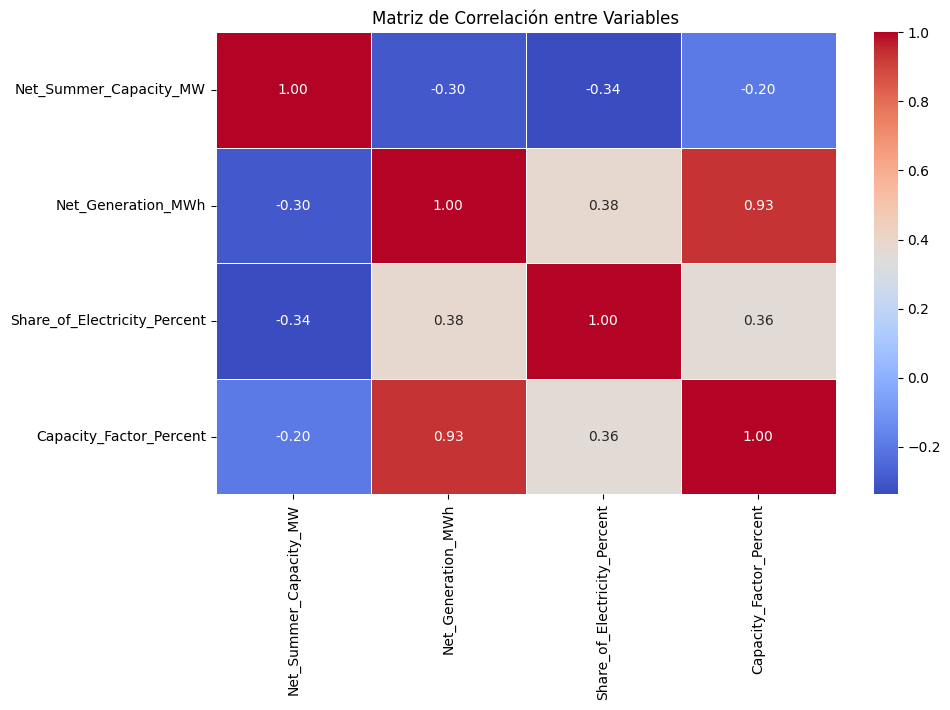

In [ ]:
# Crear un heatmap de correlación
plt.figure(figsize=(10,6))
sns.heatmap(monthly_data_per_unit.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables")
plt.show()


###Análisis del gráfico de Variables por Unidad Operativa

A pesar de que en los gráficos generales, no parecia haber un patrón claro de crecimiento ascendente de las variables, al ver como funciona cada variable en función de las plantas nucleares activas en cada momento, podemos ver un crecimiento claramente ascendente, en todas las variables, especialmente en la ***generación neta de energía***, y en la ***capacidad neta en verano***.

Aunque no es constante el crecimiento, si miramos a lo largo de los ultimos 30 años es claramente creciente.

#### Net summer capacity y Net generation

El crecimiento constante indica una mejora continua de tecnología que ha permitido que cada reactor produzca mas energia, y debido a que los reactores operativos han disminuido, indica mas bien una modernizacion y mejora de las propias plantas, que la creacion de nuevas plantas, lo cual seria un proceso reproducible en el futuro

#### Share if Electricity Percent

A pesar de que las plantas nucleares han disminuido en número, el porcentaje de electricidad se ha mantenido incluso crecido un poco, lo que indica la mejora de eficiencia de las plantas, pero también la aparición de nuevas tecnologías como la solar, eólica etc.

#### Capacity Factor Percent

Esto indica que cada vez cada reactor trabaja a mas capacidad durante mas tiempo


###Conclusión

Las plantas nucleares estan mejorando su tecnología, permitiendo generar energía mas eficientemente durante mas tiempo, y se esta realizando un trabajo de modernizacion, mas que de construccion de nuevas plantas



Index(['Net_Summer_Capacity_MW', 'Net_Generation_MWh',
       'Share_of_Electricity_Percent', 'Capacity_Factor_Percent'],
      dtype='object')


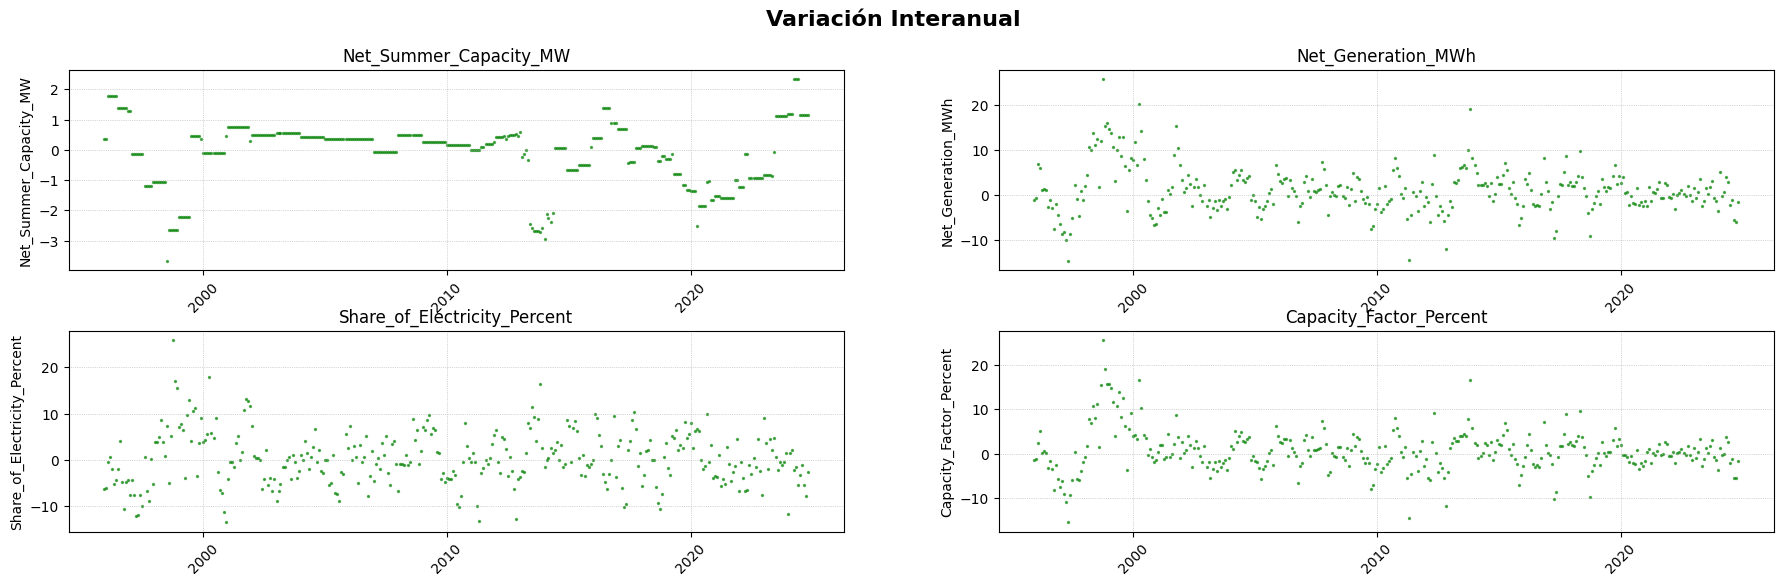

In [ ]:
#Variacion Interanual
monthly_YoY = monthly_data_per_unit.pct_change(periods=12) * 100
print(monthly_YoY.columns)


# Crear figura más grande y con más separación
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(22, 6))
axes = axes.flatten()  # Aplanar los ejes

# Estilo de puntos más limpio
scatter_style = {'color': 'green', 'alpha': 0.6, 's': 2}  # Tamaño de puntos más pequeños

# Graficar cada variable como scatter plot
for i, column in enumerate(monthly_YoY.columns):
    axes[i].scatter(monthly_YoY.index, monthly_YoY[column], **scatter_style)
    axes[i].set_ylabel(column)
    axes[i].grid(True, linestyle=':', linewidth=0.5)  # Cuadrícula más sutil
    axes[i].set_title(f"{column}", fontsize=12)  # Títulos más pequeños

    # Fechas más espaciadas
    axes[i].xaxis.set_major_locator(mdates.YearLocator(10))  # Etiqueta cada 10 años
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=45, labelsize=10)

# Eliminar el último gráfico vacío (posición 5)
#fig.delaxes(axes[len(monthly_YoY.columns)])

# Título global del gráfico
fig.suptitle("Variación Interanual", fontsize=16, fontweight='bold')

# Ajustar espacios entre gráficos
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

In [ ]:
# Sumar todos los valores positivos (años de crecimiento)
crecimiento_total = monthly_YoY[monthly_YoY['Net_Generation_MWh'] > 0]['Net_Generation_MWh'].sum()

# Sumar todos los valores negativos (años de caída)
decrecimiento_total = monthly_YoY[monthly_YoY['Net_Generation_MWh'] < 0]['Net_Generation_MWh'].sum()

# Comparar ambos valores
print(f"Crecimiento total: {crecimiento_total:.2f}%")
print(f"Decrecimiento total: {decrecimiento_total:.2f}%")
print(f"Diferencia neta: {crecimiento_total + decrecimiento_total:.2f}%")


Crecimiento total: 845.77%
Decrecimiento total: -442.05%
Diferencia neta: 403.72%


### Análisis de la Variación interanual

Podemos observar que de manera general, enlos años 90 y 2000 los crecimientos y decrecimientos, se han estabilizado bastante en los últimos años, y aun que la variabilidad no es tan grande, sigue habiendo en computo general un gran crecimiento de todas las variables

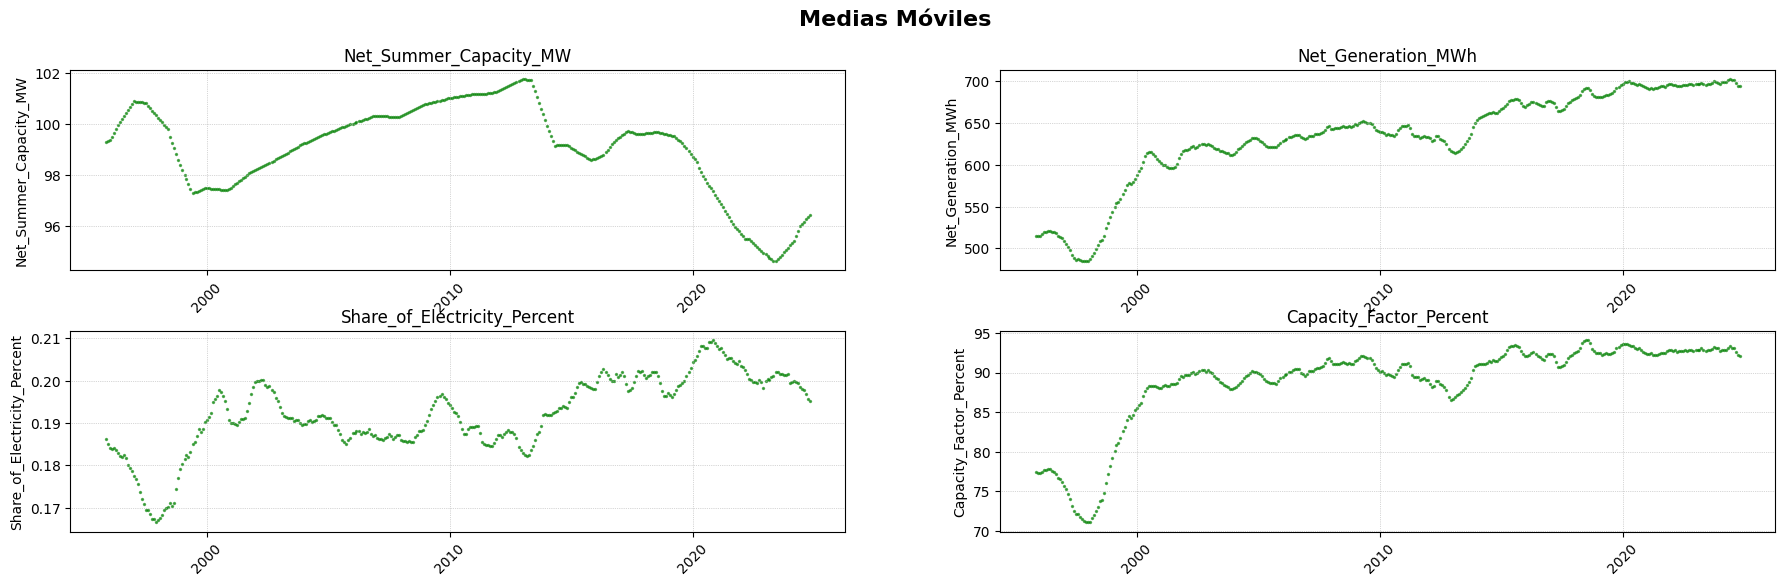

In [ ]:
#Media móvil (12 meses) Suavizar fluctuaciones mensuales
monthly_data_suavizado = monthly_data_per_unit.rolling(window=12).mean()


# Crear figura más grande y con más separación
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(22, 6))
axes = axes.flatten()  # Aplanar los ejes

# Estilo de puntos más limpio
scatter_style = {'color': 'green', 'alpha': 0.6, 's': 2}  # Tamaño de puntos más pequeños

# Graficar cada variable como scatter plot
for i, column in enumerate(monthly_data_suavizado.columns):
    axes[i].scatter(monthly_data_suavizado.index, monthly_data_suavizado[column], **scatter_style)
    axes[i].set_ylabel(column)
    axes[i].grid(True, linestyle=':', linewidth=0.5)  # Cuadrícula más sutil
    axes[i].set_title(f"{column}", fontsize=12)  # Títulos más pequeños

    # Fechas más espaciadas
    axes[i].xaxis.set_major_locator(mdates.YearLocator(10))  # Etiqueta cada 10 años
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=45, labelsize=10)

# Eliminar el último gráfico vacío (posición 5)
#fig.delaxes(axes[len(monthly_data_suavizado.columns)])

# Título global del gráfico
fig.suptitle("Medias Móviles", fontsize=16, fontweight='bold')

# Ajustar espacios entre gráficos
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()


In [ ]:
#monthly_data_suavizado

### Análisis de medias móviles

Si ponemos la media a 1 año, vemos de mejor manera esa tendencia ascendente de las variables, aun que todavia con cierta variabilidad, y con picos de 1995 hasta 2004 y de 2012 a 2017 sin embargo, si la ponemos a 5 años podemos ver esos picos desde el año 2000 al 2004 y de los 2012 al 2017

Como interpretamos esto?

¿Qué nos dice esto sobre la historia de la energía nuclear en EE.UU.?


Los períodos 2000-2004 y 2012-2017 fueron momentos de crecimiento en la eficiencia nuclear.

El crecimiento no fue uniforme → Hubo períodos donde la generación aumentó significativamente y luego se estabilizó.

Eventos específicos pueden explicar estos picos:

2000-2004 → Optimización tecnológica y mejoras operativas en las centrales existentes.

2012-2017 → Modernización de reactores y optimización del ciclo de combustible.

In [ ]:
ejecutar = False  # Cambia a True o False según la condición que desees

if ejecutar:

    monthly_data_diff = monthly_data_per_unit.diff()

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(22, 6))
    axes = axes.flatten()

    scatter_style = {'color': 'green', 'alpha': 0.6, 's': 2}

    for i, column in enumerate(monthly_data_diff.columns):
        axes[i].scatter(monthly_data_diff.index, monthly_data_diff[column], **scatter_style)
        axes[i].set_ylabel(column)
        axes[i].grid(True, linestyle=':', linewidth=0.5)
        axes[i].set_title(f"{column}", fontsize=12)

        axes[i].xaxis.set_major_locator(mdates.YearLocator(10))
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        axes[i].tick_params(axis='x', rotation=45, labelsize=10)

    fig.suptitle("Diferencia Mes a Mes", fontsize=16, fontweight='bold')
    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    plt.show()

    crecimiento_total = monthly_data_diff[monthly_data_diff['Net_Generation_MWh'] > 0]['Net_Generation_MWh'].sum()
    decrecimiento_total = monthly_data_diff[monthly_data_diff['Net_Generation_MWh'] < 0]['Net_Generation_MWh'].sum()

    print(f"Crecimiento total: {crecimiento_total:.2f}")
    print(f"Decrecimiento total: {decrecimiento_total:.2f}")
    print(f"Diferencia neta: {crecimiento_total + decrecimiento_total:.2f}")

else:
    print("El código no se ha ejecutado dado que da la misma informacion que la variación interanual.")

El código no se ha ejecutado dado que da la misma informacion que la variación interanual.


In [ ]:
ejecutar_segundo_bloque = False  # Cambia a True o False según la condición que desees

if ejecutar_segundo_bloque:
    monthly_data_log = np.log1p(monthly_data_per_unit)

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(22, 6))
    axes = axes.flatten()

    scatter_style = {'color': 'green', 'alpha': 0.6, 's': 2}

    for i, column in enumerate(monthly_data_log.columns):
        axes[i].scatter(monthly_data_log.index, monthly_data_log[column], **scatter_style)
        axes[i].set_ylabel(column)
        axes[i].grid(True, linestyle=':', linewidth=0.5)
        axes[i].set_title(f"{column}", fontsize=12)

        axes[i].xaxis.set_major_locator(mdates.YearLocator(10))
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        axes[i].tick_params(axis='x', rotation=45, labelsize=10)

    fig.suptitle("Escala Logarítmica", fontsize=16, fontweight='bold')
    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    plt.show()

    # Aquí podrías realizar cálculos adicionales si es necesario

else:
    print("No se ejecuta por que la escala logartmica al igual que las medias moviles suaviaza pero no aporta información.")


No se ejecuta por que la escala logartmica al igual que las medias moviles suaviaza pero no aporta información.


In [ ]:
from ydata_profiling import ProfileReport

# Generar el reporte de pandas-profiling
profile = ProfileReport(monthly_data_per_unit, title="Reporte de Análisis Exploratorio de Datos", explorative=True)

# Mostrar el reporte
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 52.66it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

#Resumen del Análisis de los Datos y sus Transformaciones

En todas las variables y sus distintas transformaciones, podemos notar que hay una tendencia ascendente, con ciertos periodos en los cuales hay un mayor crecimiento (2000-2004 y 2012-2017), a pesar de que la cantidad de reactores activos ha disminuido, aunque no de manera drástica.

Esto nos indica que, a lo largo de los años, la tecnología ha ido mejorando, con posibles grandes avances en campos relacionados con la energía nuclear, como la física nuclear, la física de materiales y la termodinámica, entre otros. Además, las políticas y estrategias de la industria parecen haberse centrado más en modernizar las plantas ya existentes en lugar de construir nuevas.

También es posible que el coste de construir una nueva planta nuclear sea, al menos a corto plazo, mayor que invertir en mejorar las ya existentes, lo que podría explicar esta tendencia (sería interesante investigarlo más a fondo).

El modelo SARIMAX se ajusta bastante bien a los datos, pero creo que una regresion lineal con ML podria "captar" ese patrón de cada x años haber una evolucion tecnologica y por tanto hacer otro "pico" de subida

In [ ]:
!pip install --upgrade skforecast

In [ ]:
# Data manipulation
# ==============================================================================
import numpy as np
import pandas as pd
from skforecast.datasets import fetch_dataset

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 10

# Modeling and Forecasting
# ==============================================================================
import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import skforecast
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import backtesting_forecaster
from skforecast.preprocessing import RollingFeatures
from skforecast.utils import save_forecaster
from skforecast.utils import load_forecaster
import shap

# Warnings configuration
# ==============================================================================
import warnings
warnings.filterwarnings('once')

color = '\033[1m\033[38;5;208m'
print(f"{color}Version skforecast: {skforecast.__version__}")
print(f"{color}Version scikit-learn: {sklearn.__version__}")
print(f"{color}Version pandas: {pd.__version__}")
print(f"{color}Version numpy: {np.__version__}")

Version skforecast: 0.15.1
Version scikit-learn: 1.6.1
Version pandas: 2.2.2
Version numpy: 2.0.2


In [ ]:
from sklearn.preprocessing import StandardScaler

#Escalador
scaler = StandardScaler()
X_data=[]
# Seleccionar variables exógenas (sin Net_Generation_MWh)
Var_exogenas = ["Share_of_Electricity_Percent", "Capacity_Factor_Percent", "Net_Summer_Capacity_MW"] #"Net_Summer_Capacity_MW"
X_data = monthly_data_per_unit[Var_exogenas]

# Escalar las variables exógenas
X_escalado = scaler.fit_transform(X_data)

# Convertir de nuevo a DataFrame con los mismos nombres de columnas
X_escalado = pd.DataFrame(X_escalado, columns=Var_exogenas, index=monthly_data_per_unit.index)

# Convertir la fecha en variable numérica (YYYYMM)
X_escalado["Date"] = monthly_data_per_unit.index.year * 100 + monthly_data_per_unit.index.month

# Resetear el índice para evitar problemas
X_escalado.reset_index(drop=True, inplace=True)

# Seleccionar la variable dependiente
Y_data = monthly_data_per_unit["Net_Generation_MWh"].reset_index(drop=True)

X_escalado.head(), Y_data.head()

Y_copy_forecasting = Y_data.copy()
X_copy_forecasting = X_escalado.copy()

# Convertir "Date" en datetime (si aún no lo es)
X_copy_forecasting["Date"] = pd.to_datetime(X_copy_forecasting["Date"], format="%Y%m")

# Crear copias para evitar modificar los datos originales
X_copy_forecasting = X_copy_forecasting.copy()
Y_copy_forecasting = Y_copy_forecasting.copy()

# Asignar "Date" como índice
X_copy_forecasting.set_index("Date", inplace=True)  # Elimina la columna "Date" y la pone como índice
Y_copy_forecasting.index = X_copy_forecasting.index  # Asegurar que tengan el mismo índice


# Verificar la estructura final
#Y_copy_forecasting.head(), Y_copy_forecasting.tail(),X_copy_forecasting.head(), X_copy_forecasting.tail()


In [ ]:
Y_copy_forecasting.head(), X_copy_forecasting.head()

(Date
 1994-12-01    555.018349
 1995-01-01    581.119266
 1995-02-01    475.761468
 1995-03-01    475.963303
 1995-04-01    452.486239
 Name: Net_Generation_MWh, dtype: float64,
             Share_of_Electricity_Percent  Capacity_Factor_Percent  \
 Date                                                                
 1994-12-01                      0.932479                -0.823461   
 1995-01-01                      1.060166                -0.341676   
 1995-02-01                     -0.216701                -1.342306   
 1995-03-01                     -0.663605                -2.268815   
 1995-04-01                     -0.472075                -2.404703   
 
             Net_Summer_Capacity_MW  
 Date                                
 1994-12-01                0.058121  
 1995-01-01                0.058121  
 1995-02-01                0.058121  
 1995-03-01                0.058121  
 1995-04-01                0.058121  )

In [ ]:
Y_copy_forecasting = Y_copy_forecasting.asfreq('MS')
Y_copy_forecasting

,Net_Generation_MWh
Date,
1994-12-01,555.018349
1995-01-01,581.119266
1995-02-01,475.761468
1995-03-01,475.963303
1995-04-01,452.486239
...,...
2024-07-01,743.457447
2024-08-01,742.127660
2024-09-01,666.595745


Método Recursivo -> MAE: 49.35, RMSE: 57.94
Método Directo   -> MAE: 43.44, RMSE: 50.62


<ipython-input-52-1e7387520bfa>:65: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(start=Y_copy_forecasting.index[-1], periods=steps+1, freq='M')[1:], pred_recursive,


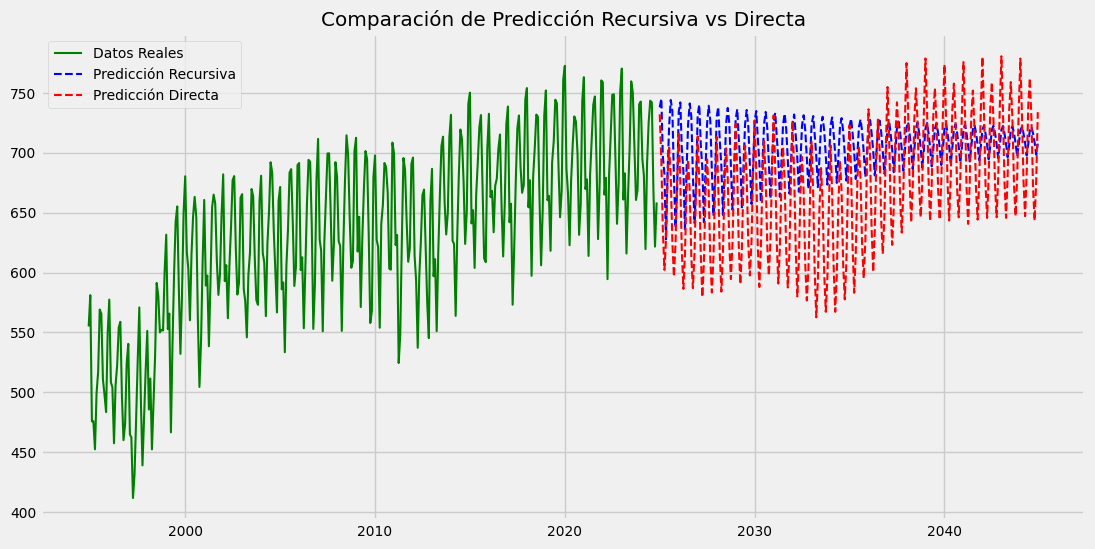

In [ ]:


# 1️⃣ **Preprocesamiento y selección de datos**
# Suponemos que Y_data es una serie temporal con un índice de tiempo
Y_copy_forecasting = Y_copy_forecasting.asfreq('MS')  # Asegurar que la frecuencia sea mensual
scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y_copy_forecasting.values.reshape(-1, 1)).flatten()  # Escalar datos

# Convertimos Y_scaled en un DataFrame para facilitar el modelado
Y_data_scaled = pd.Series(Y_scaled, index=Y_data.index)

# 2️⃣ **Definir parámetros de predicción**
años=20
lags = [6,12,24]  # Usaremos los últimos 12 meses para predecir
steps = años*12  # Queremos predecir los próximos años

# 3️⃣ **Definir modelos**
model_ridge = Ridge()

# 4️⃣ **Método Recursivo (Autoregresivo)**
forecaster_recursive = ForecasterRecursive(
    regressor=model_ridge,
    lags=lags
)

# Entrenar modelo recursivo
forecaster_recursive.fit(Y_data_scaled)

# Hacer predicción con método recursivo
pred_recursive = forecaster_recursive.predict(steps=steps)

# 5️⃣ **Método Directo**
forecaster_direct = ForecasterDirect(
    regressor=model_ridge,
    steps=steps,
    lags=lags
)

# Entrenar modelo directo
forecaster_direct.fit(Y_data_scaled)

# Hacer predicción con método directo
pred_direct = forecaster_direct.predict()

# 6️⃣ **Desescalar los resultados**
pred_recursive = scaler.inverse_transform(pred_recursive.values.reshape(-1, 1)).flatten()
pred_direct = scaler.inverse_transform(pred_direct.values.reshape(-1, 1)).flatten()

# 7️⃣ **Evaluación (solo si tenemos datos reales para comparar)**
real_values = Y_copy_forecasting[-steps:]  # Últimos valores reales

mae_recursive = mean_absolute_error(real_values, pred_recursive)
rmse_recursive = np.sqrt(mean_squared_error(real_values, pred_recursive))

mae_direct = mean_absolute_error(real_values, pred_direct)
rmse_direct = np.sqrt(mean_squared_error(real_values, pred_direct))

# Imprimir resultados
print(f"Método Recursivo -> MAE: {mae_recursive:.2f}, RMSE: {rmse_recursive:.2f}")
print(f"Método Directo   -> MAE: {mae_direct:.2f}, RMSE: {rmse_direct:.2f}")

# 8️⃣ **Graficar los resultados**
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(Y_copy_forecasting.index, Y_copy_forecasting, label="Datos Reales", color='green', linestyle="solid")
plt.plot(pd.date_range(start=Y_copy_forecasting.index[-1], periods=steps+1, freq='M')[1:], pred_recursive,
         label="Predicción Recursiva", color='blue', linestyle="dashed")
plt.plot(pd.date_range(start=Y_copy_forecasting.index[-1], periods=steps+1, freq='M')[1:], pred_direct,
         label="Predicción Directa", color='red', linestyle="dashed")
plt.legend()
plt.title("Comparación de Predicción Recursiva vs Directa")
plt.grid(True)
plt.show()


<ipython-input-53-9851c57d2ea1>:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pred_recursive_series = pd.Series(pred_recursive, index=pd.date_range(start=Y_copy_forecasting.index[-1], periods=steps, freq='M'))


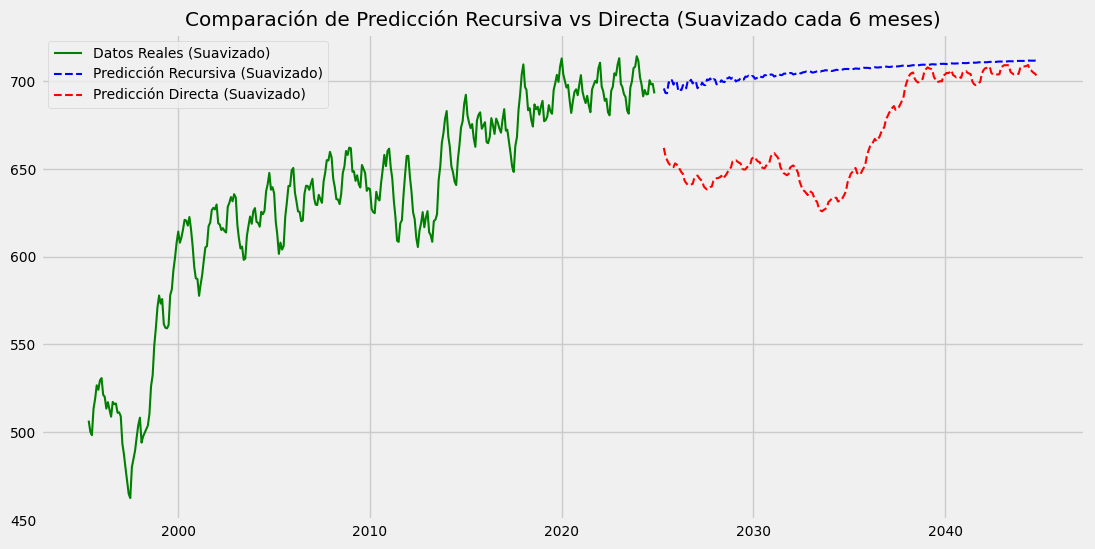

In [ ]:
import matplotlib.pyplot as plt

# Aplicar media móvil de 6 meses a los datos reales
Y_smooth = Y_copy_forecasting.rolling(window=6).mean()

# Aplicar media móvil a las predicciones
pred_recursive_series = pd.Series(pred_recursive, index=pd.date_range(start=Y_copy_forecasting.index[-1], periods=steps, freq='M'))
pred_recursive_smooth = pred_recursive_series.rolling(window=6).mean()

pred_direct_series = pd.Series(pred_direct, index=pd.date_range(start=Y_copy_forecasting.index[-1], periods=steps, freq='M'))
pred_direct_smooth = pred_direct_series.rolling(window=6).mean()

# Graficar
plt.figure(figsize=(12,6))
plt.plot(Y_copy_forecasting.index, Y_smooth, label="Datos Reales (Suavizado)", color='green', linestyle="solid")
plt.plot(pred_recursive_smooth.index, pred_recursive_smooth, label="Predicción Recursiva (Suavizado)", color='blue', linestyle="dashed")
plt.plot(pred_direct_smooth.index, pred_direct_smooth, label="Predicción Directa (Suavizado)", color='red', linestyle="dashed")

plt.legend()
plt.title("Comparación de Predicción Recursiva vs Directa (Suavizado cada 6 meses)")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
monthly_data_suavizado_ml = monthly_data_suavizado.loc['19951201':]
print(monthly_data_suavizado_ml)
# Escalador
scaler = StandardScaler()
X_data = []

# Seleccionar variables exógenas (sin Net_Generation_MWh)
Var_exogenas = ["Share_of_Electricity_Percent", "Capacity_Factor_Percent", "Net_Summer_Capacity_MW"]
X_data = monthly_data_suavizado_ml[Var_exogenas]

# Escalar las variables exógenas
X_escalado_suavizado = scaler.fit_transform(X_data)

# Convertir de nuevo a DataFrame con los mismos nombres de columnas
X_escalado_suavizado = pd.DataFrame(X_escalado_suavizado, columns=Var_exogenas, index=monthly_data_suavizado_ml.index)

# Convertir la fecha en variable numérica (YYYYMM)
X_escalado_suavizado["Date"] = monthly_data_suavizado_ml.index.year * 100 + monthly_data_suavizado_ml.index.month

# Resetear el índice para evitar problemas
X_escalado_suavizado.reset_index(drop=True, inplace=True)

# Seleccionar la variable dependiente
Y_data_suavizado = monthly_data_suavizado_ml["Net_Generation_MWh"].reset_index(drop=True)

# Mostrar las primeras filas para verificar
X_escalado_suavizado.head(), Y_data_suavizado.head()


            Net_Summer_Capacity_MW  Net_Generation_MWh  \
Date                                                     
1995-12-01               99.331500          514.833333   
1996-01-01               99.362083          514.527523   
1996-02-01               99.508750          517.250431   
1996-03-01               99.655417          519.612580   
1996-04-01               99.802083          520.030393   
...                            ...                 ...   
2024-07-01               96.083333          701.947037   
2024-08-01               96.176167          701.296385   
2024-09-01               96.269000          698.100511   
2024-10-01               96.361833          694.856183   
2024-11-01               96.454667          693.948877   

            Share_of_Electricity_Percent  Capacity_Factor_Percent  
Date                                                               
1995-12-01                      0.185092                77.358333  
1996-01-01                      0.184021 

(   Share_of_Electricity_Percent  Capacity_Factor_Percent  \
 0                     -0.798058                -2.111923   
 1                     -0.918566                -2.125727   
 2                     -0.926156                -2.096585   
 3                     -0.916140                -2.041367   
 4                     -0.949006                -2.038299   
 
    Net_Summer_Capacity_MW    Date  
 0                0.144123  199512  
 1                0.161396  199601  
 2                0.244229  199602  
 3                0.327062  199603  
 4                0.409895  199604  ,
 0    514.833333
 1    514.527523
 2    517.250431
 3    519.612580
 4    520.030393
 Name: Net_Generation_MWh, dtype: float64)

RMSE (Suavizado): 3.645631812831546
MAE (Suavizado): 2.657114345181635
Mean (Suavizado): 634.2499910932739
Coeficientes Net Generation (Suavizado): [ 2.57486239e+00  3.47412901e+01 -1.67425715e+00  2.53971515e-02] -4470.530895932071


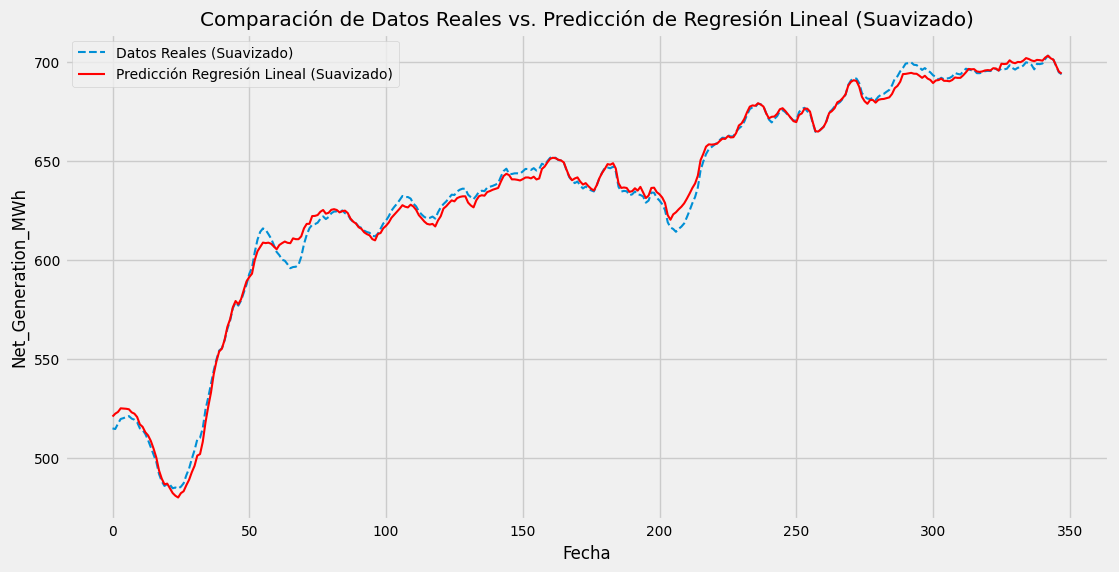

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Crear una instancia del modelo de regresión lineal
model_lr_suavizado = LinearRegression()

# Ajustar el modelo con los datos suavizados
history = model_lr_suavizado.fit(X_escalado_suavizado, Y_data_suavizado)

# Hacer predicciones con el modelo entrenado
Y_pred_suavizado = model_lr_suavizado.predict(X_escalado_suavizado)

# Calcular métricas de evaluación
rmse_suavizado = np.sqrt(mean_squared_error(Y_data_suavizado, Y_pred_suavizado))
print("RMSE (Suavizado):", rmse_suavizado)

mae_suavizado = mean_absolute_error(Y_data_suavizado, Y_pred_suavizado)
print("MAE (Suavizado):", mae_suavizado)

# Promedio de los datos reales suavizados
print("Mean (Suavizado):", Y_data_suavizado.mean())

# Coeficientes del modelo de regresión lineal
print("Coeficientes Net Generation (Suavizado):", model_lr_suavizado.coef_, model_lr_suavizado.intercept_)

# Graficar los resultados
# Graficar los resultados
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.plot(Y_data_suavizado.index, Y_data_suavizado, label="Datos Reales (Suavizado)", linestyle="dashed")
plt.plot(Y_data_suavizado.index, Y_pred_suavizado, label="Predicción Regresión Lineal (Suavizado)", color='red')

# Configurar las etiquetas del eje X para que usen el formato de 'Date' de X_escalado_suavizado
#plt.xticks(X_escalado_suavizado['Date'], labels=X_escalado_suavizado['Date'].astype(str), rotation=45)

plt.legend()
plt.title("Comparación de Datos Reales vs. Predicción de Regresión Lineal (Suavizado)")
plt.xlabel("Fecha")
plt.ylabel("Net_Generation_MWh")

plt.show()

La regresion se realiza bien, para el net generation, pero la proyeccion de net summer capacity, no se ajusta muy bien, por tanto lo suyo seria quitar los datos <1980 para evitar esos outlayers y de esta manera ser mas realista

Con la regresion lineal los valores son:

Evaluación del modelo de Net Generation:

R²: 0.6601

MSE: 3104.6570

MAE: 45.7593


Evaluación del modelo de Net Summer Capacity:

R²: 0.0269

MSE: 4.7402

MAE: 1.5042



Con un polinomio de grado 2 los valores son:

Evaluación del modelo polinómico de Net Generation:

R²: 0.7302

MSE: 2464.9615

MAE: 40.9800


Evaluación del modelo polinómico de Net Summer Capacity:

R²: 0.5449

MSE: 2.2168

MAE: 1.1500

